# CNN final version: five-class vehicle classification

This notebook implements the CNN sequence presented in the lecture:

**input image -> convolution -> ReLU -> max pooling -> flatten -> fully connected layer -> softmax output**

The five classes are **airplanes, buses, cars, motorcycles, and ship**. Run every cell from top to bottom using the project `.venv` kernel. The notebook uses a custom CNN rather than a pretrained network so that every lecture component is visible.


## Lecture-to-notebook alignment

| Lecture concept | Implementation in this notebook |
|---|---|
| Five image classes | `CLASS_NAMES` contains airplanes, buses, cars, motorcycles, and ship |
| Supervised labels | Folder names provide the correct class for each image |
| One-hot encoding | `class_mode="categorical"` produces a vector of length 5 |
| Convolution and shared filters | Four `Conv2D` layers learn feature maps |
| ReLU | Every convolution and hidden dense layer uses `activation="relu"` |
| Pooling | A `MaxPooling2D` layer follows every convolution |
| Vectorization | `Flatten` changes the final feature maps into one vector |
| Fully connected classification | `Dense(128)` combines the extracted features |
| Class probabilities | The final `Dense(5, activation="softmax")` returns five probabilities |
| Loss | `categorical_crossentropy` compares softmax output with the one-hot target |
| CNN training | `model.fit` performs forward pass, loss, backpropagation, and weight update |
| Simulation results | Accuracy/loss curves, test metrics, confusion matrix, and image prediction |

The lecture's homework asks for **five classes of input images** and visible **simulation results**. This notebook implements both requirements.


## 1. Imports and reproducible configuration

`CLASS_NAMES` defines the output-neuron order. Folder names, one-hot labels, predictions, and the saved JSON file all use this same order.


In [16]:
# LECTURE CONNECTION:
# TensorFlow/Keras supplies the CNN layers and training algorithm.
# A fixed random seed makes data shuffling and initial weights more reproducible.
# Five class names mean the final softmax layer must contain exactly five neurons.

from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ["airplanes", "buses", "cars", "motorcycles", "ship"]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 30

TRAIN_DIR = Path("Datasets/train/images_datasets")
TEST_DIR = Path("Datasets/test")
MODEL_PATH = Path("cnn_final_model.keras")
CLASS_NAMES_PATH = Path("class_names.json")

print("TensorFlow version:", tf.__version__)
print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


TensorFlow version: 2.16.2
Classes: ['airplanes', 'buses', 'cars', 'motorcycles', 'ship']
Number of classes: 5


## 2. Validate and count the dataset

The training folder contains 500 source images (100 per class). A 20% validation split gives **400 training images** and **100 validation images**. Validation images remain in the same folders; Keras selects them internally. The separate test directory contains 100 held-out images.


In [17]:
# LECTURE CONNECTION:
# Supervised CNN training requires an image and a correct class label for every sample.
# These checks confirm that all five class folders exist and contain readable image files.
# Keeping the class counts balanced prevents one vehicle class from dominating training.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}


def count_images(folder):
    return sum(
        path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        for path in folder.iterdir()
    )


for split_name, root in (("training source", TRAIN_DIR), ("test", TEST_DIR)):
    if not root.is_dir():
        raise FileNotFoundError(f"Missing dataset directory: {root.resolve()}")

    print(f"\n{split_name.title()} data: {root}")
    for class_name in CLASS_NAMES:
        class_dir = root / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Missing class directory: {class_dir}")
        count = count_images(class_dir)
        if count == 0:
            raise ValueError(f"No images found in: {class_dir}")
        print(f"  {class_name:<12}: {count:>3} images")



Training Source data: Datasets/train/images_datasets
  airplanes   : 100 images
  buses       : 100 images
  cars        : 100 images
  motorcycles : 100 images
  ship        : 100 images

Test data: Datasets/test
  airplanes   :  20 images
  buses       :  20 images
  cars        :  20 images
  motorcycles :  20 images
  ship        :  20 images


## 3. Create training, validation, and test generators

- Training images receive small random transformations to reduce overfitting.
- Validation and test images are not augmented.
- `class_mode="categorical"` creates five-element one-hot target vectors.
- Pixel rescaling is inside the model, so training and single-image prediction use identical preprocessing.


In [18]:
# LECTURE CONNECTION:
# class_mode='categorical' converts each class into a five-value one-hot vector.
# The 20% validation split selects 100 of the 500 source images for validation;
# it does not create or move physical validation files. Augmentation affects training only.

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    validation_split=0.20,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

evaluation_datagen = keras.preprocessing.image.ImageDataGenerator(
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED,
)

validation_generator = evaluation_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED,
)

test_generator = keras.preprocessing.image.ImageDataGenerator().flow_from_directory(
    TEST_DIR,
    classes=CLASS_NAMES,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

expected_indices = {name: index for index, name in enumerate(CLASS_NAMES)}
assert train_generator.class_indices == expected_indices
assert validation_generator.class_indices == expected_indices
assert test_generator.class_indices == expected_indices

print("Class indices:", train_generator.class_indices)
print("Training batches per epoch:", len(train_generator))
print("Validation batches per epoch:", len(validation_generator))
print("Test batches:", len(test_generator))


Found 400 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Class indices: {'airplanes': 0, 'buses': 1, 'cars': 2, 'motorcycles': 3, 'ship': 4}
Training batches per epoch: 25
Validation batches per epoch: 7
Test batches: 7


### Preview one training batch

The displayed labels are obtained from the one-hot vectors with `argmax`.


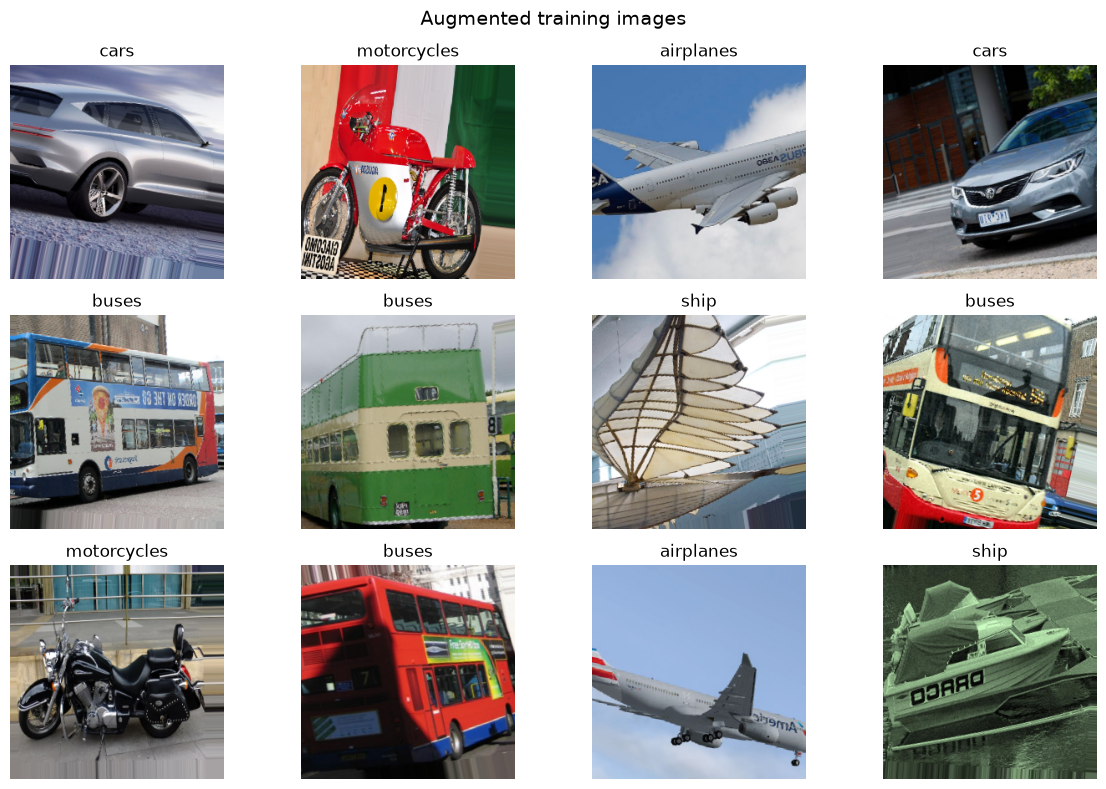

In [19]:
# LECTURE CONNECTION:
# A batch is a small group of images processed in one forward/backward pass.
# argmax changes a one-hot vector such as [0, 0, 0, 0, 1] back to class index 4
# only for displaying its readable label; training still uses the full one-hot vector.

images, one_hot_labels = next(train_generator)

plt.figure(figsize=(12, 8))
for index in range(min(12, len(images))):
    plt.subplot(3, 4, index + 1)
    plt.imshow(images[index].astype("uint8"))
    class_index = int(np.argmax(one_hot_labels[index]))
    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.suptitle("Augmented training images", fontsize=14)
plt.tight_layout()
plt.show()
train_generator.reset()


## 4. Build the CNN from the lecture

Each `Conv2D` layer learns feature maps using shared kernels. ReLU replaces negative activations with zero. `MaxPooling2D` reduces spatial dimensions. `Flatten` converts the final feature maps into a vector, and the dense layers perform classification. The last layer has five softmax neurons, one for each class.


### Layer-by-layer dimensions

The model uses `padding="same"`, so convolution preserves width and height. Each `2 x 2` max-pooling operation divides width and height by two.

| Stage | Output shape for one image | Meaning |
|---|---:|---|
| Input | `256 x 256 x 3` | RGB image |
| Conv 1 | `256 x 256 x 32` | 32 learned feature maps |
| Pool 1 | `128 x 128 x 32` | Spatial size divided by 2 |
| Conv 2 | `128 x 128 x 64` | 64 feature maps |
| Pool 2 | `64 x 64 x 64` | Spatial size divided by 2 |
| Conv 3 | `64 x 64 x 128` | 128 higher-level feature maps |
| Pool 3 | `32 x 32 x 128` | Spatial size divided by 2 |
| Conv 4 | `32 x 32 x 128` | 128 high-level feature maps |
| Pool 4 | `16 x 16 x 128` | Final pooled feature maps |
| Flatten | `32768` | `16 x 16 x 128` values become one vector |
| Dense | `128` | Fully connected learned representation |
| Softmax | `5` | One probability for each vehicle class |

ReLU applies `max(0, x)`: negative activations become zero. Softmax converts the final five scores into probabilities whose sum is approximately 1.


In [20]:
# LECTURE CONNECTION:
# Convolution learns shared filters that create feature maps. ReLU keeps positive
# activations, max pooling reduces width and height, and Flatten makes one vector.
# The dense layer combines learned features; softmax returns five probabilities
# whose sum is 1.0. 'same' padding preserves size before each pooling operation.

model = keras.Sequential(
    [
        layers.Input(shape=IMAGE_SIZE + (3,), name="rgb_image"),
        layers.Rescaling(1.0 / 255, name="normalize_pixels"),  # Map pixels from 0-255 to 0-1.

        layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_1"),
        layers.MaxPooling2D((2, 2), name="pool_1"),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_2"),
        layers.MaxPooling2D((2, 2), name="pool_2"),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="conv_3"),
        layers.MaxPooling2D((2, 2), name="pool_3"),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="conv_4"),
        layers.MaxPooling2D((2, 2), name="pool_4"),

        layers.Flatten(name="flatten_feature_maps"),  # Convert 3-D feature maps to one vector.
        layers.Dense(128, activation="relu", name="fully_connected"),  # Combine extracted features.
        layers.Dropout(0.40, name="dropout"),  # Reduce overfitting during training.
        layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities"),  # Five probabilities.
    ],
    name="five_class_vehicle_cnn",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",  # Appropriate loss for one-hot multi-class labels.
    metrics=["accuracy"],
)

model.summary()


Model: "five_class_vehicle_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalize_pixels (Rescaling)    │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_feature_maps (Flatten)  │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fully_connected (Dense)         │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,435,909 (16.92 MB)

 Trainable params: 4,435,909 (16.92 MB)

 Non-trainable params: 0 (0.00 B)

## 4A. Hand calculation of every layer output shape

This code follows the same formula used on the convolution summary slide:

`output = floor((input + 2 x padding - kernel) / stride) + 1`

For `padding="same"`, a `3 x 3` convolution with stride 1 uses padding 1, so width and height stay unchanged. A `2 x 2` pooling layer with stride 2 and padding 0 divides them by two. The number after the final `x` is the number of filters (feature maps), not a value produced by the spatial-size formula.


In [ ]:
# HAND CALCULATION OF THE SHAPES SHOWN IN THE TABLE ABOVE.
# These are the exact arithmetic steps represented internally by Keras.
from math import floor


def slide_output_size(input_size, kernel_size, padding, stride):
    return floor((input_size + 2 * padding - kernel_size) / stride) + 1


height, width, channels = 256, 256, 3
calculated_shapes = [("Input", height, width, channels)]

print(f"Input: {height} x {width} x {channels}")

filter_counts = [32, 64, 128, 128]
for layer_number, filters in enumerate(filter_counts, start=1):
    input_height, input_width = height, width

    # Conv2D: 3 x 3 kernel, padding 1 ('same'), stride 1.
    height = slide_output_size(input_height, 3, 1, 1)
    width = slide_output_size(input_width, 3, 1, 1)
    channels = filters
    calculated_shapes.append((f"Conv {layer_number}", height, width, channels))
    print(
        f"Conv {layer_number}: floor(({input_height} + 2(1) - 3) / 1) + 1 "
        f"= {height}; output = {height} x {width} x {channels}"
    )

    # MaxPooling2D: 2 x 2 window, padding 0 ('valid'), stride 2.
    input_height, input_width = height, width
    height = slide_output_size(input_height, 2, 0, 2)
    width = slide_output_size(input_width, 2, 0, 2)
    calculated_shapes.append((f"Pool {layer_number}", height, width, channels))
    print(
        f"Pool {layer_number}: floor(({input_height} + 2(0) - 2) / 2) + 1 "
        f"= {height}; output = {height} x {width} x {channels}"
    )

flatten_size = height * width * channels
dense_size = 128
softmax_size = NUM_CLASSES

print(f"Flatten: {height} x {width} x {channels} = {flatten_size}")
print(f"Dense output: {dense_size} neurons")
print(f"Softmax output: {softmax_size} class probabilities")

expected_shapes = [
    ("Input", 256, 256, 3),
    ("Conv 1", 256, 256, 32),
    ("Pool 1", 128, 128, 32),
    ("Conv 2", 128, 128, 64),
    ("Pool 2", 64, 64, 64),
    ("Conv 3", 64, 64, 128),
    ("Pool 3", 32, 32, 128),
    ("Conv 4", 32, 32, 128),
    ("Pool 4", 16, 16, 128),
]
assert calculated_shapes == expected_shapes
assert flatten_size == 32768
assert softmax_size == 5
print("\nAll hand-calculated output shapes match the CNN model.")


### Hand calculation of trainable parameters

For a convolution layer:

`parameters = (kernel height x kernel width x input channels + one bias) x filters`

For a dense layer:

`parameters = input values x neurons + one bias per neuron`


In [ ]:
# HAND CALCULATION OF THE PARAMETER COUNTS IN model.summary().
conv_1_parameters = (3 * 3 * 3 + 1) * 32
conv_2_parameters = (3 * 3 * 32 + 1) * 64
conv_3_parameters = (3 * 3 * 64 + 1) * 128
conv_4_parameters = (3 * 3 * 128 + 1) * 128
dense_parameters = (32768 + 1) * 128
softmax_parameters = (128 + 1) * 5

parameter_calculations = {
    "Conv 1": conv_1_parameters,
    "Conv 2": conv_2_parameters,
    "Conv 3": conv_3_parameters,
    "Conv 4": conv_4_parameters,
    "Dense": dense_parameters,
    "Softmax": softmax_parameters,
}

print("Conv 1: (3 x 3 x 3 + 1) x 32 =", conv_1_parameters)
print("Conv 2: (3 x 3 x 32 + 1) x 64 =", conv_2_parameters)
print("Conv 3: (3 x 3 x 64 + 1) x 128 =", conv_3_parameters)
print("Conv 4: (3 x 3 x 128 + 1) x 128 =", conv_4_parameters)
print("Dense:  (32768 + 1) x 128 =", dense_parameters)
print("Output: (128 + 1) x 5 =", softmax_parameters)
print("Total trainable parameters =", sum(parameter_calculations.values()))

assert parameter_calculations == {
    "Conv 1": 896,
    "Conv 2": 18496,
    "Conv 3": 73856,
    "Conv 4": 147584,
    "Dense": 4194432,
    "Softmax": 645,
}
assert sum(parameter_calculations.values()) == 4435909
print("\nAll hand-calculated parameter counts match model.summary().")


## 4B. Slide-style manual CNN calculation with numerical values

The model above lets Keras perform the calculations automatically. This section exposes the same operations numerically, using the input and `2 x 2` kernel from the lecture exercise.

The calculation order is:

**convolution + bias -> ReLU -> max pooling -> flatten -> fully connected logits -> softmax -> cross-entropy**

For convolution output position `(i, j)`:

`z[i,j] = sum(input patch * kernel) + bias`

ReLU then calculates `max(0, z[i,j])`. The code uses assertions so an incorrect hand calculation stops the cell immediately.


In [ ]:
# SLIDE CALCULATION: convolution, bias, ReLU, max pooling, and flattening.
slide_input = np.array(
    [
        [0.51, 0.90, 0.88, 0.84, 0.05],
        [0.40, 0.62, 0.22, 0.59, 0.10],
        [0.11, 0.20, 0.74, 0.33, 0.14],
        [0.47, 0.01, 0.85, 0.70, 0.09],
        [0.76, 0.19, 0.72, 0.17, 0.57],
    ],
    dtype=np.float64,
)
slide_kernel = np.array([[-0.13, 0.15], [0.19, 0.62]], dtype=np.float64)
slide_bias = 1.0


def manual_valid_convolution(image, kernel, bias=0.0, stride=1):
    # CNN-style cross-correlation: element-wise multiply, sum, then add bias.
    out_h = (image.shape[0] - kernel.shape[0]) // stride + 1
    out_w = (image.shape[1] - kernel.shape[1]) // stride + 1
    output = np.empty((out_h, out_w), dtype=np.float64)
    for out_row in range(out_h):
        for out_col in range(out_w):
            row = out_row * stride
            col = out_col * stride
            patch = image[row : row + kernel.shape[0], col : col + kernel.shape[1]]
            output[out_row, out_col] = np.sum(patch * kernel) + bias
    return output


convolution_output = manual_valid_convolution(slide_input, slide_kernel, slide_bias)
relu_output = np.maximum(0.0, convolution_output)

# The first output explicitly verifies the slide's multiply-and-add process.
first_patch = slide_input[:2, :2]
first_value = np.sum(first_patch * slide_kernel) + slide_bias
assert np.isclose(first_value, convolution_output[0, 0])

# 2 x 2 max pooling with stride 2 converts the 4 x 4 map into 2 x 2.
pooled_output = np.array(
    [
        [np.max(relu_output[r : r + 2, c : c + 2]) for c in range(0, 4, 2)]
        for r in range(0, 4, 2)
    ]
)
flattened_vector = pooled_output.flatten()

print("First 2 x 2 input patch:\n", first_patch)
print("\nFirst convolution calculation:")
print("(0.51 x -0.13) + (0.90 x 0.15) + (0.40 x 0.19) + (0.62 x 0.62) + 1")
print(f"= {first_value:.4f}")
print("\nConvolution + bias output (4 x 4):\n", np.round(convolution_output, 4))
print("\nAfter ReLU (4 x 4):\n", np.round(relu_output, 4))
print("\nAfter 2 x 2 max pooling, stride 2 (2 x 2):\n", np.round(pooled_output, 4))
print("\nFlattened vector (length 4):\n", np.round(flattened_vector, 4))


### Fully connected, softmax, and cross-entropy calculation

The lecture's two-neuron exercise uses sigmoid. For this notebook's mutually exclusive five-class problem, the correct output is instead five logits followed by softmax:

`p[c] = exp(z[c]) / sum(exp(z))`

With a one-hot target, categorical cross-entropy simplifies to:

`loss = -ln(probability assigned to the correct class)`


In [ ]:
# SLIDE CALCULATION: one fully connected five-class output and its loss.
# Rows correspond to the four flattened inputs; columns correspond to five classes.
demo_dense_weights = np.array(
    [
        [0.61, 0.02, -0.20, 0.15, 0.30],
        [0.82, -0.50, 0.10, 0.25, -0.10],
        [0.96, 0.23, 0.35, -0.30, 0.20],
        [-1.00, 0.17, 0.40, 0.10, 0.05],
    ],
    dtype=np.float64,
)
demo_dense_bias = np.full(5, 0.20, dtype=np.float64)

logits = flattened_vector @ demo_dense_weights + demo_dense_bias

# Subtracting max(logits) gives the same softmax probabilities more safely.
stable_logits = logits - np.max(logits)
exp_logits = np.exp(stable_logits)
softmax_probabilities = exp_logits / np.sum(exp_logits)

correct_class_index = 4  # ship in CLASS_NAMES
one_hot_target = np.eye(NUM_CLASSES)[correct_class_index]
cross_entropy_terms = -one_hot_target * np.log(softmax_probabilities)
manual_loss = np.sum(cross_entropy_terms)
shortcut_loss = -np.log(softmax_probabilities[correct_class_index])

assert np.isclose(np.sum(softmax_probabilities), 1.0)
assert np.isclose(manual_loss, shortcut_loss)

print("Dense logits:", np.round(logits, 4))
print("Softmax probabilities:", np.round(softmax_probabilities, 4))
print("Probability sum:", np.sum(softmax_probabilities))
print("One-hot target:", one_hot_target.astype(int))
print(f"Cross-entropy = -ln(p_correct) = -ln({softmax_probabilities[correct_class_index]:.6f})")
print(f"Loss = {manual_loss:.6f}")
print("Predicted class:", CLASS_NAMES[int(np.argmax(softmax_probabilities))])


### Average pooling comparison from the lecture

The trained CNN correctly uses max pooling. This extra calculation covers the lecture's average-pooling concept without changing the model architecture.


In [ ]:
# The pooling matrix from the lecture.
pooling_example = np.array(
    [
        [12, 20, 30, 0],
        [8, 12, 2, 0],
        [34, 70, 37, 4],
        [112, 100, 25, 12],
    ],
    dtype=np.float64,
)

max_pool_example = np.array(
    [[np.max(pooling_example[r:r+2, c:c+2]) for c in range(0, 4, 2)] for r in range(0, 4, 2)]
)
average_pool_example = np.array(
    [[np.mean(pooling_example[r:r+2, c:c+2]) for c in range(0, 4, 2)] for r in range(0, 4, 2)]
)

assert np.array_equal(max_pool_example, np.array([[20, 30], [112, 37]]))
assert np.allclose(average_pool_example, np.array([[13, 8], [79, 19.5]]))

print("Max pooling:\n", max_pool_example)
print("\nAverage pooling (exact values):\n", average_pool_example)
print("\nThe slide rounds 19.5 to 20 in its displayed result.")


## 5. Train and save the best model

During the forward pass, the model produces class probabilities and categorical cross-entropy measures the error. Backpropagation calculates gradients; Adam updates weights in the direction that reduces the loss. Early stopping prevents unnecessary training after validation performance stops improving.


### What happens during training

For each batch, training repeats four lecture stages:

1. **Forward pass:** images move through convolution, ReLU, pooling, flattening, the fully connected layer, and softmax.
2. **Loss calculation:** categorical cross-entropy compares the five predicted probabilities with the five-value one-hot label.
3. **Backward pass:** automatic differentiation calculates the gradient of loss with respect to every trainable weight.
4. **Weight update:** Adam changes the weights in the direction that reduces the loss.

For a one-hot target, categorical cross-entropy can be written as:

`L = -sum(y_c * log(p_c))`

Only the correct class has `y_c = 1`. Therefore, assigning a high probability to the correct class produces a small loss; assigning it a low probability produces a large loss.


In [21]:
# LECTURE CONNECTION:
# model.fit performs repeated forward passes, loss calculation, backpropagation,
# and weight updates. Categorical cross-entropy compares five softmax probabilities
# with the five-value one-hot target. Validation loss is used to select the best epoch.

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

model = keras.models.load_model(MODEL_PATH)
CLASS_NAMES_PATH.write_text(json.dumps(CLASS_NAMES, indent=2), encoding="utf-8")
print(f"Best model saved to: {MODEL_PATH.resolve()}")


Epoch 1/30

Epoch 1: val_loss improved from None to 1.57525, saving model to cnn_final_model.keras

Epoch 1: finished saving model to cnn_final_model.keras
25/25 - 5s - 190ms/step - accuracy: 0.2475 - loss: 1.6348 - val_accuracy: 0.2000 - val_loss: 1.5753 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 1.57525 to 1.55229, saving model to cnn_final_model.keras

Epoch 2: finished saving model to cnn_final_model.keras
25/25 - 4s - 143ms/step - accuracy: 0.3575 - loss: 1.4941 - val_accuracy: 0.3200 - val_loss: 1.5523 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_loss improved from 1.55229 to 1.32166, saving model to cnn_final_model.keras

Epoch 3: finished saving model to cnn_final_model.keras
25/25 - 4s - 141ms/step - accuracy: 0.4225 - loss: 1.3956 - val_accuracy: 0.4500 - val_loss: 1.3217 - learning_rate: 0.0010
Epoch 4/30

Epoch 4: val_loss improved from 1.32166 to 1.21974, saving model to cnn_final_model.keras

Epoch 4: finished saving model to cnn_final_model.k

## 6. Plot the simulation results

These graphs compare training and validation accuracy/loss across epochs. A widening gap between training and validation performance is evidence of overfitting.


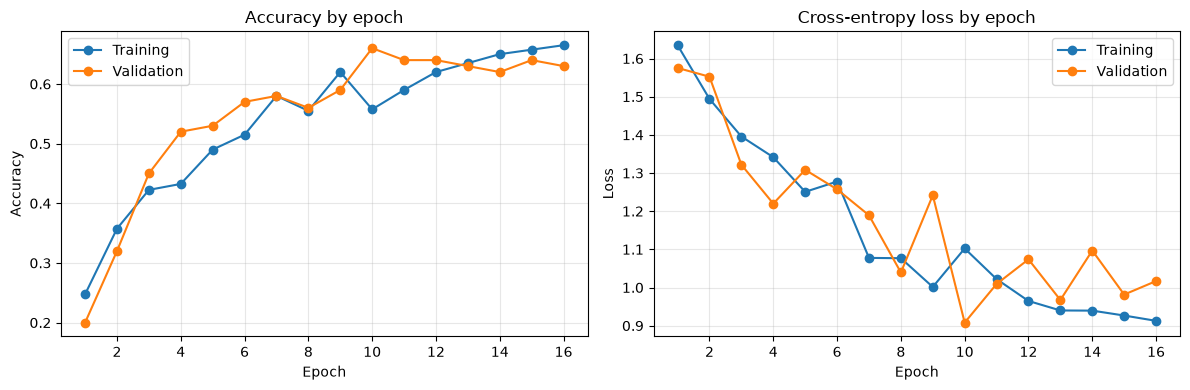

In [22]:
# LECTURE CONNECTION:
# These curves are the requested simulation results. Accuracy measures correct
# classifications, while cross-entropy loss measures probability error. Comparing
# training with validation curves helps reveal underfitting or overfitting.

epochs_run = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_run, history.history["accuracy"], marker="o", label="Training")
plt.plot(epochs_run, history.history["val_accuracy"], marker="o", label="Validation")
plt.title("Accuracy by epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_run, history.history["loss"], marker="o", label="Training")
plt.plot(epochs_run, history.history["val_loss"], marker="o", label="Validation")
plt.title("Cross-entropy loss by epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## 7. Evaluate unseen test images

Accuracy gives the overall result. Precision, recall, and F1-score show performance for each class. The confusion matrix shows which vehicle classes the CNN confuses.


### How to explain the simulation results

- **Training accuracy** measures correct predictions on augmented training batches.
- **Validation accuracy** measures generalization to the held-out 20% of training-source images.
- **Test accuracy** measures performance on the separate test directory, which was not used for weight updates.
- **Precision** asks: when the model predicts a class, how often is it correct?
- **Recall** asks: of all real images in a class, how many did the model find?
- **F1-score** balances precision and recall.
- In the **confusion matrix**, diagonal cells are correct predictions and off-diagonal cells show which classes are confused.

If training accuracy rises while validation accuracy stays low or validation loss rises, the model is overfitting. Early stopping and dropout help reduce this problem.


Test images: 100
Test loss: 0.8105
Test accuracy: 70.00%

              precision    recall  f1-score   support

   airplanes     0.7500    0.7500    0.7500        20
       buses     0.6154    0.8000    0.6957        20
        cars     0.8824    0.7500    0.8108        20
 motorcycles     0.7222    0.6500    0.6842        20
        ship     0.5789    0.5500    0.5641        20

    accuracy                         0.7000       100
   macro avg     0.7098    0.7000    0.7010       100
weighted avg     0.7098    0.7000    0.7010       100



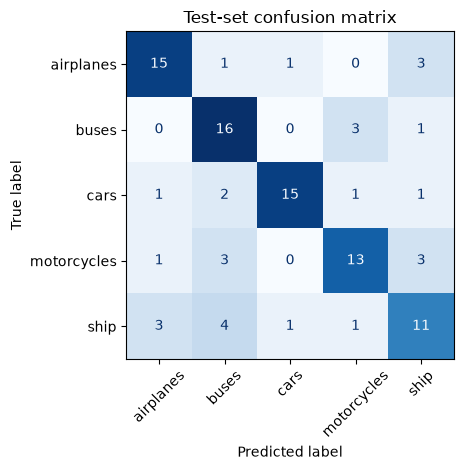

In [23]:
# LECTURE CONNECTION:
# The test set is held out from training and validation, so it estimates performance
# on unseen data. A confusion matrix shows actual classes by predicted classes;
# diagonal cells are correct predictions and off-diagonal cells are mistakes.

test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

test_generator.reset()
probabilities = model.predict(test_generator, verbose=0)
predicted_classes = np.argmax(probabilities, axis=1)
true_classes = test_generator.classes

print(f"Test images: {test_generator.samples}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}\n")
print(
    classification_report(
        true_classes,
        predicted_classes,
        labels=range(NUM_CLASSES),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    labels=range(NUM_CLASSES),
    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
)
plt.title("Test-set confusion matrix")
plt.tight_layout()
plt.show()


## 8. Predict one image

The model returns five softmax probabilities. `argmax` selects the class with the largest probability. This function reads the label order from `class_names.json`, preventing a mismatch between training and prediction.


In [24]:
# LECTURE CONNECTION:
# Single-image inference uses the same image size and normalization as training.
# The network performs a forward pass, softmax produces one probability per class,
# and argmax selects the position of the largest probability as the prediction.

def test_single_image(image_path, model_path=MODEL_PATH, labels_path=CLASS_NAMES_PATH):
    image_path = Path(image_path)
    model_path = Path(model_path)
    labels_path = Path(labels_path)

    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")
    if not model_path.is_file():
        raise FileNotFoundError(f"Model not found: {model_path}. Train the model first.")
    if not labels_path.is_file():
        raise FileNotFoundError(f"Class-name file not found: {labels_path}")

    saved_class_names = json.loads(labels_path.read_text(encoding="utf-8"))
    prediction_model = keras.models.load_model(model_path)
    if prediction_model.output_shape[-1] != len(saved_class_names):
        raise ValueError("Saved model output size and class-name count do not match.")

    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    image_array = keras.utils.img_to_array(image)
    image_batch = np.expand_dims(image_array, axis=0)

    probabilities = prediction_model.predict(image_batch, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_class = saved_class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    colors = ["crimson" if i == predicted_index else "steelblue" for i in range(len(saved_class_names))]
    bars = plt.bar(saved_class_names, probabilities * 100, color=colors)
    plt.title("Softmax class probabilities")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 105)
    plt.xticks(rotation=35, ha="right")
    for bar, probability in zip(bars, probabilities):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{probability:.1%}",
            ha="center",
        )
    plt.tight_layout()
    plt.show()

    print(f"Image: {image_path.name}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    print("\nAll class probabilities:")
    for label, probability in zip(saved_class_names, probabilities):
        print(f"  {label:<12}: {probability:.2%}")

    return predicted_class, confidence, probabilities


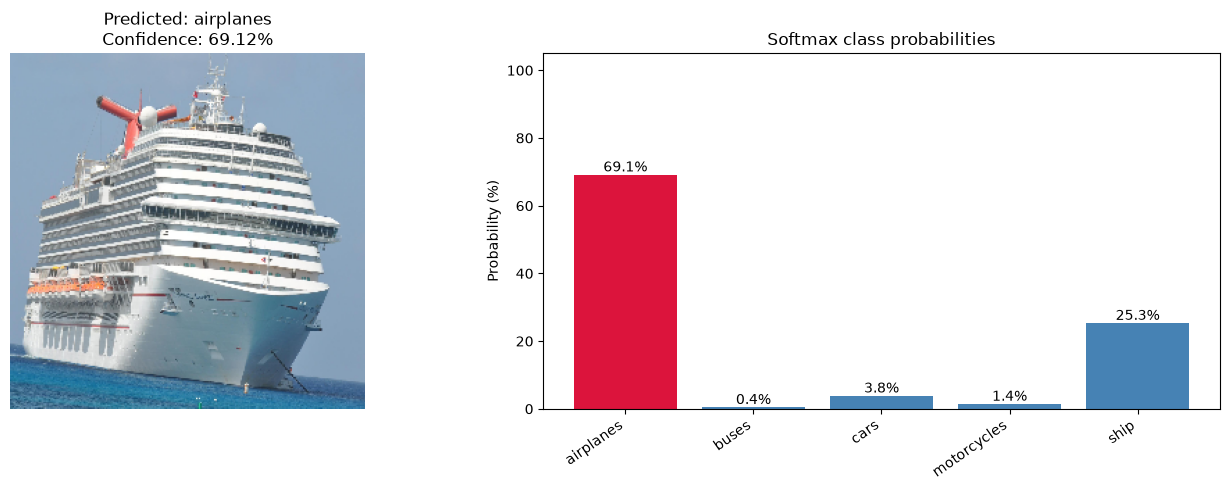

Image: ship_020.jpg
Predicted class: airplanes
Confidence: 69.12%

All class probabilities:
  airplanes   : 69.12%
  buses       : 0.41%
  cars        : 3.80%
  motorcycles : 1.39%
  ship        : 25.27%


('airplanes',
 0.6912248134613037,
 array([0.6912248 , 0.0041239 , 0.0380347 , 0.01392799, 0.2526886 ],
       dtype=float32))

In [28]:
# Run the complete prediction pipeline on one held-out ship image.
# Change only this path when you want to demonstrate a different test image.

# Change this path to test another image.
test_single_image("Datasets/test/ship/ship_020.jpg")


## 9. What to include in the homework submission

After running all cells, show:

1. The five class names and dataset counts.
2. Example input images.
3. `model.summary()` as evidence of convolution, ReLU, pooling, flattening, fully connected, and softmax stages.
4. Training/validation accuracy and loss graphs.
5. Test accuracy, per-class classification report, and confusion matrix.
6. At least one single-image prediction with all five probabilities.

The progress value such as `7/7` is the number of test **batches**, not classes. With 100 test images and batch size 16, `ceil(100 / 16) = 7` batches.
